<a href="https://colab.research.google.com/github/rathore-rl1lmg1/Cooding-Playground/blob/main/Untitled3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv('/content/sample_data/mnist_train_small.csv')
data = np.array(data)
m , n = data.shape
np.random.shuffle(data)
print(n)

785


In [ ]:
data_dev = data[0:1000].T
Y_dev = data_dev[0].astype(int) # Ensure labels are integers
X_dev = data_dev[1:n]
X_dev = X_dev / 255.

data_train = data[1000:m].T
y_train = data_train[0].astype(int) # Ensure labels are integers
x_train = data_train[1:n]
x_train = x_train / 255
_,m = x_train.shape

In [ ]:
m = 19999 #num of training set
n = 9999  #num of test set
o = 10 #number of element in layer 1
p = 10  #number of element in layer 2
q = 500 #num epoch
alpha = 0.10 #learning rate
T_loss = []
T_acc = []

In [ ]:
def init_params(input_dim):
  W_1 = np.random.rand(10, input_dim) - 0.5
  b_1 = np.random.rand(10, 1) - 0.5
  W_2 = np.random.rand(10, 10) - 0.5
  b_2 = np.random.rand(10, 1) - 0.5
  return W_1 , b_1 , W_2 , b_2

In [ ]:
def Relu(z):
  return np.maximum(0,z)

def softmax(z):
    return np.exp(z) / sum(np.exp(z))

def forward_pause(x,w_1,w_2,b_1,b_2):
    z_1 = w_1.dot(x) + b_1
    a_1 = Relu(z_1)
    z_2 = w_2.dot(a_1) + b_2
    y_hat = softmax(z_2)
    return y_hat , a_1 , z_1 , z_2

def one_hot(y):
    one_hot_y = np.zeros((y.size,y.max() + 1))
    one_hot_y[np.arange(y.size),y] = 1
    one_hot_y = one_hot_y.T
    return one_hot_y

def derivative_relu(z):
    return z > 0

def backward_pause(y_hat,a_1,z_1,z_2,w_1,w_2,y_train,x_train):
    m = y_train.size
    y = one_hot(y_train)
    d_z_2 = y_hat - y
    d_w_2 = 1/m * (d_z_2.dot(a_1.T))
    d_b_2 = 1/m * np.sum(d_z_2 , axis = 1 , keepdims = True)

    d_z_1 = w_2.T.dot(d_z_2) * (derivative_relu(z_1))
    d_w_1 = 1/m * (d_z_1.dot(x_train.T))
    d_b_1 = 1/m * np.sum(d_z_1 , axis= 1 , keepdims = True)
    return d_w_1 , d_b_1 , d_w_2 , d_b_2

def get_predictions(y_hat):
    return np.argmax(y_hat,0)

def get_accuracy(predictions,y):
    return np.sum(predictions == y)/y.size

def update_params(w_1,b_1,w_2,b_2,d_w_1,d_b_1,d_w_2,d_b_2,alpha):
    w_1 = w_1 - alpha*d_w_1
    b_1 = b_1 - alpha*d_b_1

    w_2 = w_2 - alpha*d_w_2
    b_2 = b_2 - alpha*d_b_2

    return w_1 , b_1 , w_2 , b_2

def Loss(y_hat, y, m):
    loss = -(np.sum(y * np.log(y_hat)+(1-y)*np.log(1-y_hat))/m)
    return loss

In [ ]:
w_1 , b_1 , w_2 , b_2 = init_params(x_train.shape[0])
print (x_train.shape[0])
print (w_2.shape)
y_hat , a_1 , z_1 , z_2 = forward_pause(x_train,w_1,w_2,b_1,b_2)
d_w_1 , d_b_1 , d_w_2 , d_b_2 = backward_pause(y_hat,a_1,z_1,z_2,w_1,w_2,y_train,x_train)
print (y_hat.shape)
y = one_hot(y_train)
print (y.shape)
print (y_hat)

784
(10, 10)
(10, 18999)
(10, 18999)
[[0.08192508 0.1284678  0.11899205 ... 0.08054715 0.1502714  0.12393993]
 [0.24386493 0.12871061 0.33595026 ... 0.15603929 0.18329145 0.45087685]
 [0.03405101 0.13340212 0.19655105 ... 0.15565874 0.11727661 0.05809228]
 ...
 [0.17349798 0.07981963 0.10259011 ... 0.06027047 0.07829984 0.04562159]
 [0.01311832 0.06540824 0.02898981 ... 0.04126885 0.05622076 0.00844728]
 [0.17090772 0.05653579 0.072373   ... 0.07236787 0.05733066 0.13491481]]


In [ ]:
def gradient_descent(x_train,y_train,q,alpha,T_loss,T_acc):
  w_1 , b_1 , w_2 , b_2 = init_params(x_train.shape[0]) # Pass input_dim as x_train.shape[0]
  for i in range(q):
    y_hat , a_1 , z_1 , z_2 = forward_pause(x_train,w_1,w_2,b_1,b_2)
    d_w_1 , d_b_1 , d_w_2 , d_b_2 = backward_pause(y_hat,a_1,z_1,z_2,w_1,w_2,y_train,x_train)
    w_1 , b_1 , w_2 , b_2 = update_params(w_1,b_1,w_2,b_2,d_w_1,d_b_1,d_w_2,d_b_2,alpha)
    if (i % 50 == 0):
      print("iteration: ",i)
      print("accuracy:", get_accuracy(get_predictions(y_hat),y_train))
    loss = Loss(y_hat , y, m)
    T_loss.append(loss)
    T_acc.append(get_accuracy(get_predictions(y_hat),y_train))
  return w_1 , b_1 , w_2 , b_2 , T_loss , T_acc

In [ ]:
w_1 , b_1 , w_2 , b_2 , T_loss , T_acc = gradient_descent(x_train,y_train,q,alpha , T_loss ,T_acc)

iteration:  0
accuracy: 0.09763671772198537
iteration:  50
accuracy: 0.49239433654402864
iteration:  100
accuracy: 0.672140638980999
iteration:  150
accuracy: 0.7455129217327228
iteration:  200
accuracy: 0.7856202958050423
iteration:  250
accuracy: 0.8103058055687141
iteration:  300
accuracy: 0.8266750881625349
iteration:  350
accuracy: 0.8378335701879046
iteration:  400
accuracy: 0.8470445812937523
iteration:  450
accuracy: 0.853360703194905


loss


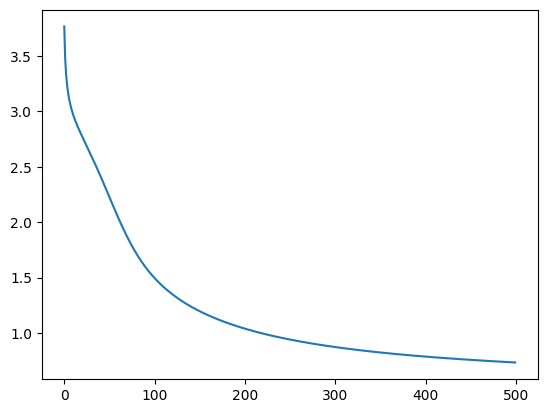

accuracy


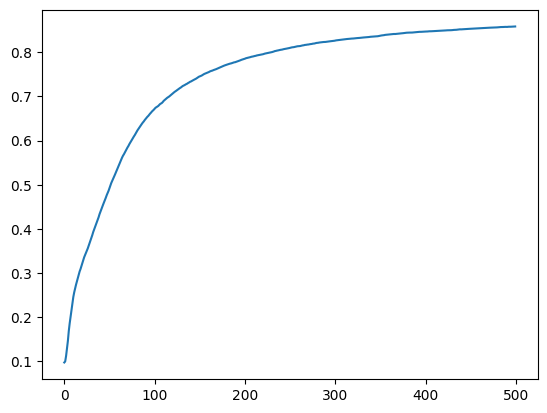

In [ ]:
print("loss")
plt.plot(T_loss)
plt.show()
print("accuracy")
plt.plot(T_acc)
plt.show()